Analisando arquivo global: cat01_non_alcoholic.csv do mercado Market_1


,date,quantity,unitvalue,onpromotion,productcost,holiday,product_id,category,market,observation,day_sin,day_cos,month,month_sin,month_cos
0,2019-01-28,20.0,0.75,1,0.8,0,7622210762894,01_non_alcoholic,Market_1,NaN,0.000000,1.000000,1,0.0,1.000000
1,2019-01-29,13.0,0.75,1,0.8,0,7622210762894,01_non_alcoholic,Market_1,NaN,0.781831,0.623490,1,0.0,1.000000
2,2019-01-30,10.0,0.99,0,0.8,0,7622210762894,01_non_alcoholic,Market_1,NaN,0.974928,-0.222521,1,0.0,1.000000
3,2019-01-31,16.0,0.99,0,0.8,0,7622210762894,01_non_alcoholic,Market_1,NaN,0.433884,-0.900969,1,0.0,1.000000
4,2019-02-01,29.0,0.99,0,0.8,0,7622210762894,01_non_alcoholic,Market_1,NaN,-0.433884,-0.900969,2,0.5,0.866025


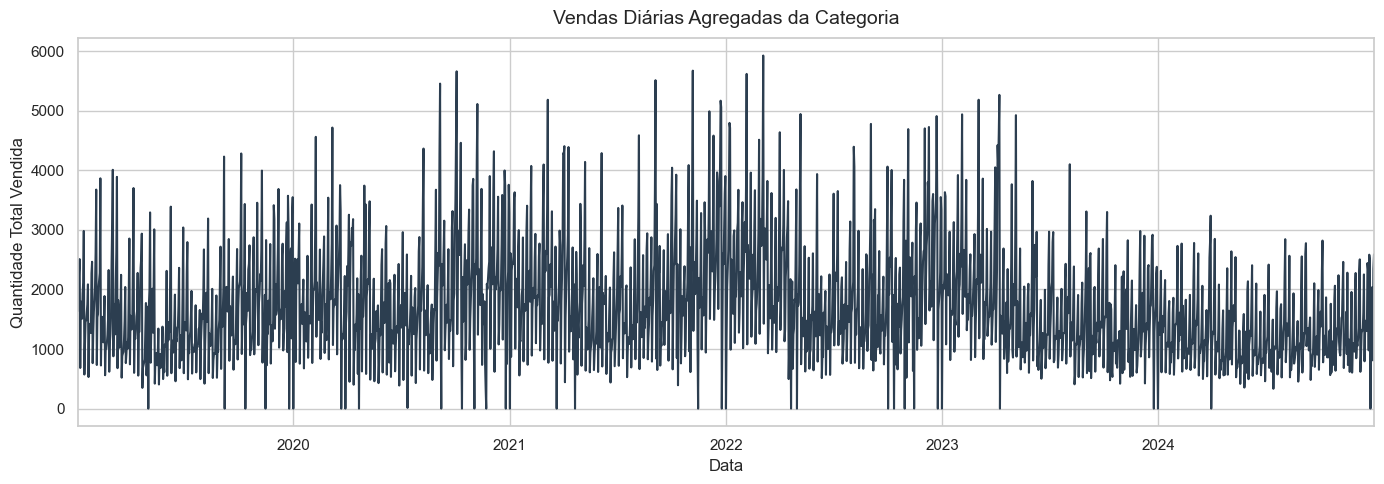

C:\Users\lucas\AppData\Local\Temp\ipykernel_14680\1771737324.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, palette="viridis")


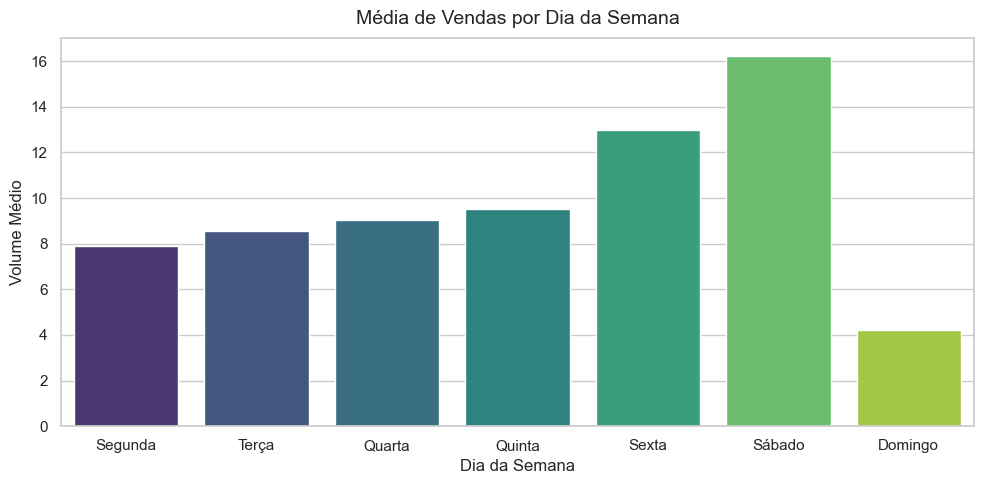

Total de registros: 391944
Registros com zero vendas: 106374
Esparsidade da Base: 27.14% dos dias não possuem vendas.


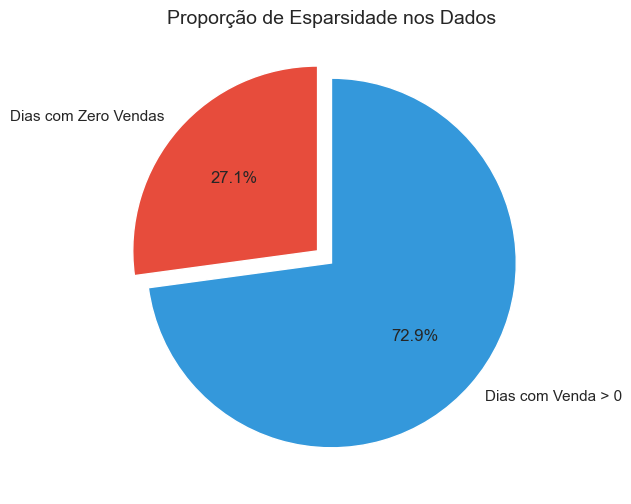

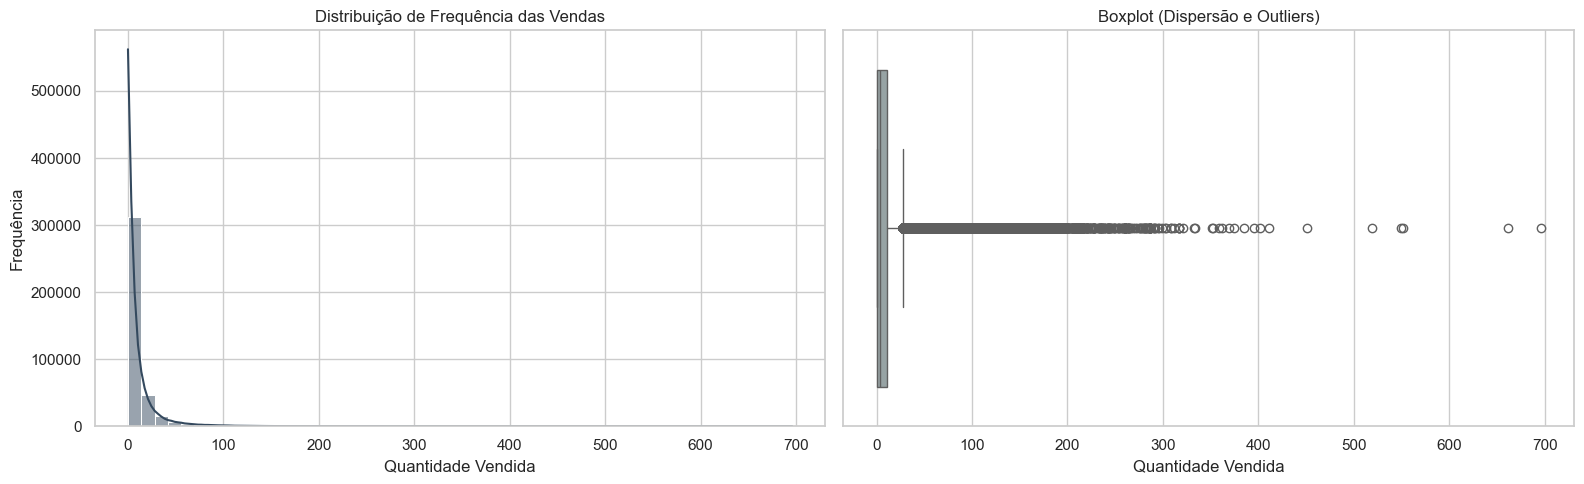

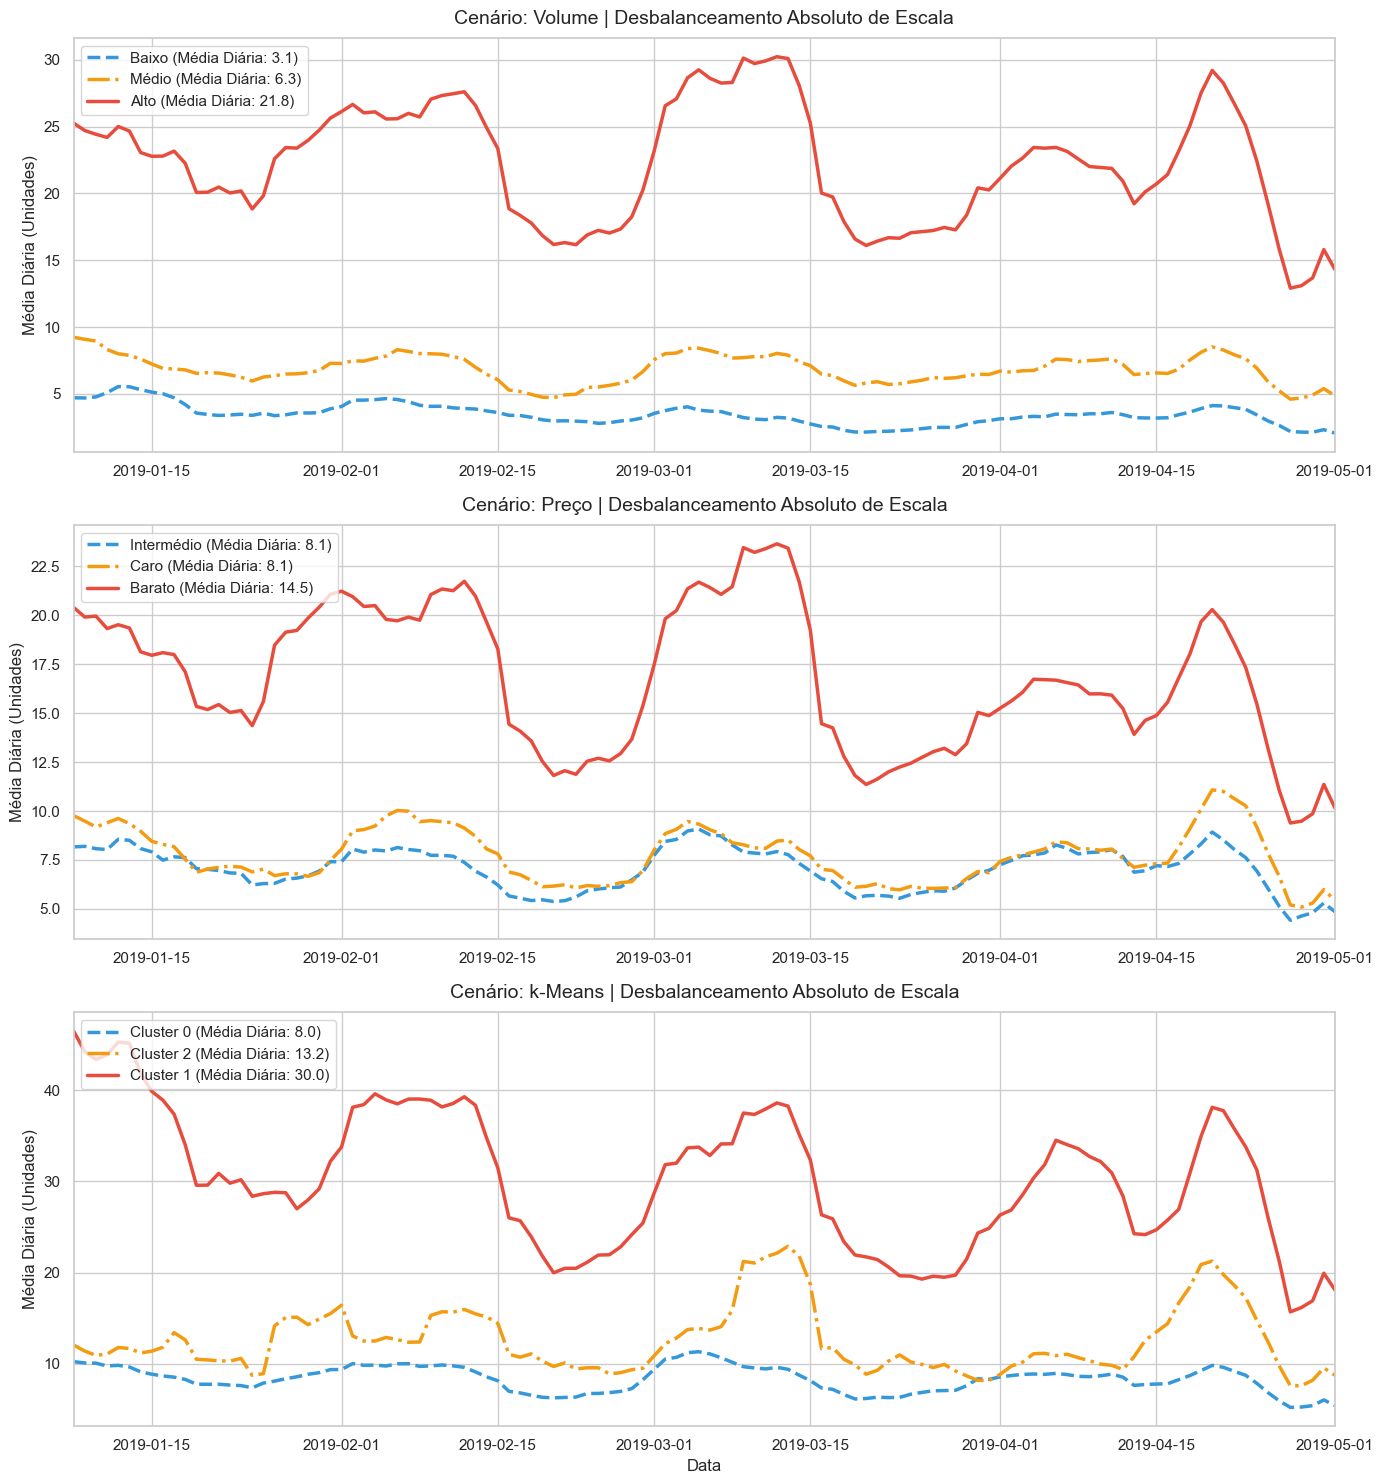

In [5]:
# %% [markdown]
# # Análise Exploratória de Dados (EDA)
# 
# ## Objetivo
# Compreender a distribuição de vendas, a sazonalidade, a esparsidade dos dados e identificar anomalias que justifiquem as escolhas metodológicas de modelagem preditiva, especificamente a estratégia *Cluster-then-Predict*.
# 
# ## Reprodutibilidade
# - **Seed global**: `42`
# - **Ambiente**: Python 3.10+ (Bibliotecas listadas em `requirements.txt`)
# 
# ## Contextualização
# A previsão de demanda no setor varejista representa um desafio significativo devido à alta variabilidade das vendas, à influência de fatores sazonais e à presença frequente de comportamentos atípicos (esparsidade). A correta compreensão desses padrões é fundamental para o desenvolvimento de modelos preditivos eficientes.
# 
# Nesse contexto, a análise exploratória dos dados desempenha um papel central, permitindo investigar a estrutura das séries temporais, justificar o isolamento de clusters e embasar a escolha das métricas de avaliação (MAE e RMSE).

# %%
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona a raiz do projeto ao sys.path para importar os módulos customizados
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.reproducibility import set_global_seed

# Configuração visual e reprodutibilidade
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
set_global_seed(42)

# Caminho base dos dados (Usando os dados já processados e padronizados)
DATA_PATH = ROOT / "Dados" / "preprocessed"

# Carrega a primeira categoria do primeiro mercado como exemplo para a análise geral
market_path = next(DATA_PATH.iterdir())
csv_file = next(market_path.glob("cat*.csv"))

print(f"Analisando arquivo global: {csv_file.name} do mercado {market_path.name}")
df = pd.read_csv(csv_file, parse_dates=["date"])

display(df.head())

# %% [markdown]
# ## 1. Análise Temporal Global
# A análise da série temporal agregada permite observar o comportamento geral das vendas ao longo do tempo, evidenciando padrões de crescimento, estabilidade ou declínio, bem como oscilações abruptas.

# %%
# Agrupando vendas totais por dia
daily_sales = df.groupby("date")["quantity"].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values, color='#2c3e50', linewidth=1.5)
plt.title("Vendas Diárias Agregadas da Categoria", fontsize=14, pad=10)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Quantidade Total Vendida", fontsize=12)
plt.xlim(daily_sales.index.min(), daily_sales.index.max())
plt.tight_layout()
plt.show()

# %% [markdown]
# > **Observação Crítica:** Nota-se elevada variabilidade na série temporal, com flutuações acentuadas entre períodos consecutivos. Esse comportamento indica forte influência de fatores externos e invalida a eficácia de modelos lineares simples, exigindo arquiteturas capazes de lidar com ruído (como XGBoost ou LSTMs).
# 
# ---
# ## 2. Sazonalidade Semanal
# A identificação de sazonalidade é crucial para embasar a criação de features cíclicas (seno/cosseno) que alimentarão os modelos.

# %%
# Extraindo o dia da semana da coluna de datas (0=Segunda, 6=Domingo)
df['day_of_week'] = df['date'].dt.dayofweek

# Analisando a média de vendas por dia da semana
weekly_pattern = df.groupby("day_of_week")["quantity"].mean()
dias_semana = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(10, 5))
sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, palette="viridis")
plt.title("Média de Vendas por Dia da Semana", fontsize=14, pad=10)
plt.xlabel("Dia da Semana", fontsize=12)
plt.ylabel("Volume Médio", fontsize=12)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.tight_layout()
plt.show()

# %% [markdown]
# > **Observação:** O perfil médio semanal evidencia diferenças significativas no volume de vendas, caracterizando uma sazonalidade bem definida. Isso justifica diretamente a engenharia de atributos (Feature Engineering) baseada em lags e variáveis temporais utilizada no projeto.
# 
# ---
# ## 3. Análise de Esparsidade (A Densidade de Zeros)
# A ausência de vendas em dias específicos é um fenômeno comum no varejo e impacta diretamente a seleção das métricas de erro.

# %%
# Calculando a porcentagem de dias com zero vendas
total_registros = len(df)
dias_zerados = len(df[df["quantity"] == 0])
percentual_zeros = (dias_zerados / total_registros) * 100

print(f"Total de registros: {total_registros}")
print(f"Registros com zero vendas: {dias_zerados}")
print(f"Esparsidade da Base: {percentual_zeros:.2f}% dos dias não possuem vendas.")

# Gráfico de pizza para ilustrar a esparsidade
plt.figure(figsize=(6, 6))
plt.pie([dias_zerados, total_registros - dias_zerados], 
        labels=['Dias com Zero Vendas', 'Dias com Venda > 0'], 
        autopct='%1.1f%%', colors=['#e74c3c', '#3498db'], startangle=90, explode=(0.1, 0))
plt.title("Proporção de Esparsidade nos Dados", fontsize=14)
plt.show()

# %% [markdown]
# > **Veredito Acadêmico:** A base de dados apresenta um grau considerável de **esparsidade**. A presença de dias zerados afeta matematicamente o cálculo de métricas de erro percentual, como o **sMAPE**, gerando distorções que penalizam excessivamente as previsões em dias de venda zero. Esta análise justifica a utilização conjunta do **MAE** (erro absoluto em unidades) e do **RMSE** (penalização de grandes desvios) como métricas primárias para a avaliação real do desempenho logístico neste trabalho.
# 
# ---
# ## 4. Distribuição e Identificação de Outliers
# A avaliação de valores extremos dita as regras de corte (clipping) no pré-processamento.

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
sns.histplot(df["quantity"], bins=50, ax=axes[0], color="#34495e", kde=True)
axes[0].set_title("Distribuição de Frequência das Vendas")
axes[0].set_xlabel("Quantidade Vendida")
axes[0].set_ylabel("Frequência")

# Boxplot
sns.boxplot(x=df["quantity"], ax=axes[1], color="#95a5a6")
axes[1].set_title("Boxplot (Dispersão e Outliers)")
axes[1].set_xlabel("Quantidade Vendida")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Justificativa da Estratégia Cluster-then-Predict (Múltiplos Cenários)
# Para comprovar a necessidade metodológica do agrupamento prévio, analisamos a diferença absoluta de escala entre todos os clusters gerados por cada uma das três estratégias (Volume, Preço e k-Means). O isolamento evita que o desbalanceamento volumétrico force os modelos matemáticos a encontrar um "meio-termo" irreal.

# %%
# Define o caminho para a pasta split que contém os ficheiros já agrupados
SPLIT_PATH = ROOT / "Dados" / "split"

# Procura um mercado que tenha os ficheiros gerados
market_split = next((m for m in SPLIT_PATH.iterdir() if m.is_dir()), None)

if market_split:
    # Mapeamento dos sufixos dos ficheiros
    scenarios = {
        "Volume": "vol",
        "Preço": "price",
        "k-Means": "kmeans"
    }
    
    # Dicionário para traduzir e padronizar os nomes dos clusters
    TRADUCAO_CLUSTERS = {
        "low": "Baixo",
        "med": "Médio",
        "high": "Alto",
        "cheap": "Barato",
        "mid": "Intermédio",
        "expensive": "Caro",
        "c0": "Cluster 0",
        "c1": "Cluster 1",
        "c2": "Cluster 2"
    }
    
    # Paleta de cores do menor para o maior volume
    cores_gradiente = ['#3498db', '#f39c12', '#e74c3c']
    estilos_linha = ['--', '-.', '-']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 15))
    
    for idx, (nome_cenario, sufixo) in enumerate(scenarios.items()):
        arquivos = list(market_split.glob(f"*{sufixo}.csv"))
        ax = axes[idx]
        
        if len(arquivos) < 2:
            ax.set_title(f"Cenário {nome_cenario}: Ficheiros insuficientes para comparação.", fontsize=14)
            continue
            
        # 1. Agrupamento correto: Junta categorias diferentes que pertencem ao mesmo cluster
        clusters_consolidados = {}
        
        for file in arquivos:
            df_temp = pd.read_csv(file, parse_dates=["date"])
            # Extrai o nome em inglês e traduz para português
            nome_original = file.stem.split('_')[-2]
            nome_pt = TRADUCAO_CLUSTERS.get(nome_original, nome_original)
            
            if nome_pt not in clusters_consolidados:
                clusters_consolidados[nome_pt] = []
            clusters_consolidados[nome_pt].append(df_temp)
            
        # 2. Calcula as médias após a consolidação
        dados_clusters = []
        for nome_cluster, lista_dfs in clusters_consolidados.items():
            # Concatena todos os DataFrames do mesmo cluster (ex: cat01_baixo + cat02_baixo)
            df_combinado = pd.concat(lista_dfs, ignore_index=True)
            media_global = df_combinado['quantity'].mean()
            dados_clusters.append({"nome": nome_cluster, "df": df_combinado, "media": media_global})
        
        # 3. Ordena do menor volume para o maior volume matemático
        dados_clusters = sorted(dados_clusters, key=lambda x: x["media"])
        
        min_date, max_date = None, None
        
        # 4. Plotagem gráfica
        for i, cluster in enumerate(dados_clusters):
            # Agrupa os primeiros 120 dias e aplica Média Móvel de 7 dias
            c_sample = cluster["df"].groupby('date')['quantity'].mean().head(120).rolling(7).mean()
            
            cor = cores_gradiente[i % len(cores_gradiente)]
            estilo = estilos_linha[i % len(estilos_linha)]
            
            ax.plot(c_sample.index, c_sample.values, color=cor, linestyle=estilo, linewidth=2.5, 
                    label=f'{cluster["nome"]} (Média Diária: {cluster["media"]:.1f})')
            
            if min_date is None or c_sample.dropna().index.min() < min_date:
                min_date = c_sample.dropna().index.min()
            if max_date is None or c_sample.index.max() > max_date:
                max_date = c_sample.index.max()
        
        ax.set_title(f"Cenário: {nome_cenario} | Desbalanceamento Absoluto de Escala", fontsize=14, pad=10)
        ax.set_ylabel('Média Diária (Unidades)', fontsize=12)
        ax.set_xlim(min_date, max_date)
        ax.legend(loc='upper left')
        
    plt.xlabel('Data', fontsize=12)
    plt.tight_layout()
    plt.show()
    
else:
    print("[ERRO] Pasta split não encontrada ou vazia.")